In [ ]:
import os, time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

tf.keras.backend.clear_session()
np.set_printoptions(precision=3, suppress=True)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, shuffle=True
)

x_train_norm = x_train_split.astype("float32") / 255.0
x_valid_norm = x_valid_split.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("train:", x_train_norm.shape, y_train_split.shape)
print("valid:", x_valid_norm.shape, y_valid_split.shape)
print("test :", x_test_norm.shape,  y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
train: (45000, 32, 32, 3) (45000, 1)
valid: (5000, 32, 32, 3) (5000, 1)
test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
def display_training_curves(training, validation, title, subplot):
    ax = plt.subplot(subplot)
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model ' + title)
    ax.set_ylabel(title)
    ax.set_xlabel('epoch')
    ax.legend(['training', 'validation'])

def plot_history_df(history, title=""):
    history_df = pd.DataFrame(history.history)

    plt.subplots(figsize=(16,12))
    plt.tight_layout()
    display_training_curves(history_df['accuracy'], history_df['val_accuracy'], f'accuracy {title}', 211)
    display_training_curves(history_df['loss'], history_df['val_loss'], f'loss {title}', 212)
    plt.show()

    return history_df

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12,10))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.5, cbar=False,
                ax=ax, cmap='Blues', linecolor='white')
    ax.set_title(title)
    plt.ylabel('true label')
    plt.xlabel('predicted label')
    plt.show()

def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer='adam',
                        batch_size=64,
                        epochs=200,
                        patience=3,
                        save_dir="/content/models"):

    os.makedirs(save_dir, exist_ok=True)
    ckpt_path = os.path.join(save_dir, f"{exp_name}.keras")

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, save_weights_only=False),
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=False)
    ]

    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = round(time.time() - t0, 2)
    print(f"Finished {exp_name} in {train_time}s")

    # IMPORTANT: load best checkpoint for fair reporting
    best_model = tf.keras.models.load_model(ckpt_path)

    return history, train_time, ckpt_path, best_model


In [ ]:
results_df = pd.DataFrame(columns=[
    "experiment","params",
    "train_loss","train_acc",
    "val_loss","val_acc",
    "test_loss","test_acc",
    "train_time_sec","optimizer","batch_size","epochs_ran"
])
results_df


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran


# Experiment 6

In [ ]:
tf.keras.backend.clear_session()

exp_name6 = "Exp6_CNN_3block_dropout"

cnn3_drop = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.50),

    Dense(10, activation='softmax')
], name=exp_name6)

cnn3_drop.summary()


Model: "Exp6_CNN_3block_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 167ms/step - accuracy: 0.2565 - loss: 1.9806 - val_accuracy: 0.4566 - val_loss: 1.4913
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.4597 - loss: 1.4802 - val_accuracy: 0.5294 - val_loss: 1.2856
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 111s 158ms/step - accuracy: 0.5406 - loss: 1.2997 - val_accuracy: 0.5958 - val_loss: 1.1483
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.5715 - loss: 1.1961 - val_accuracy: 0.6596 - val_loss: 0.9522
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 158ms/step - accuracy: 0.6060 - loss: 1.1131 - val_accuracy: 0.6736 - val_loss: 0.9281
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 155ms/step - accuracy: 0.6300 - loss: 1.0533 - val_accuracy: 0.6884 - val_loss: 0.8827
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.6445 - loss: 1.0143 - val_accuracy: 0.6838 - val_loss: 0.8836
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 156ms/step - accuracy: 

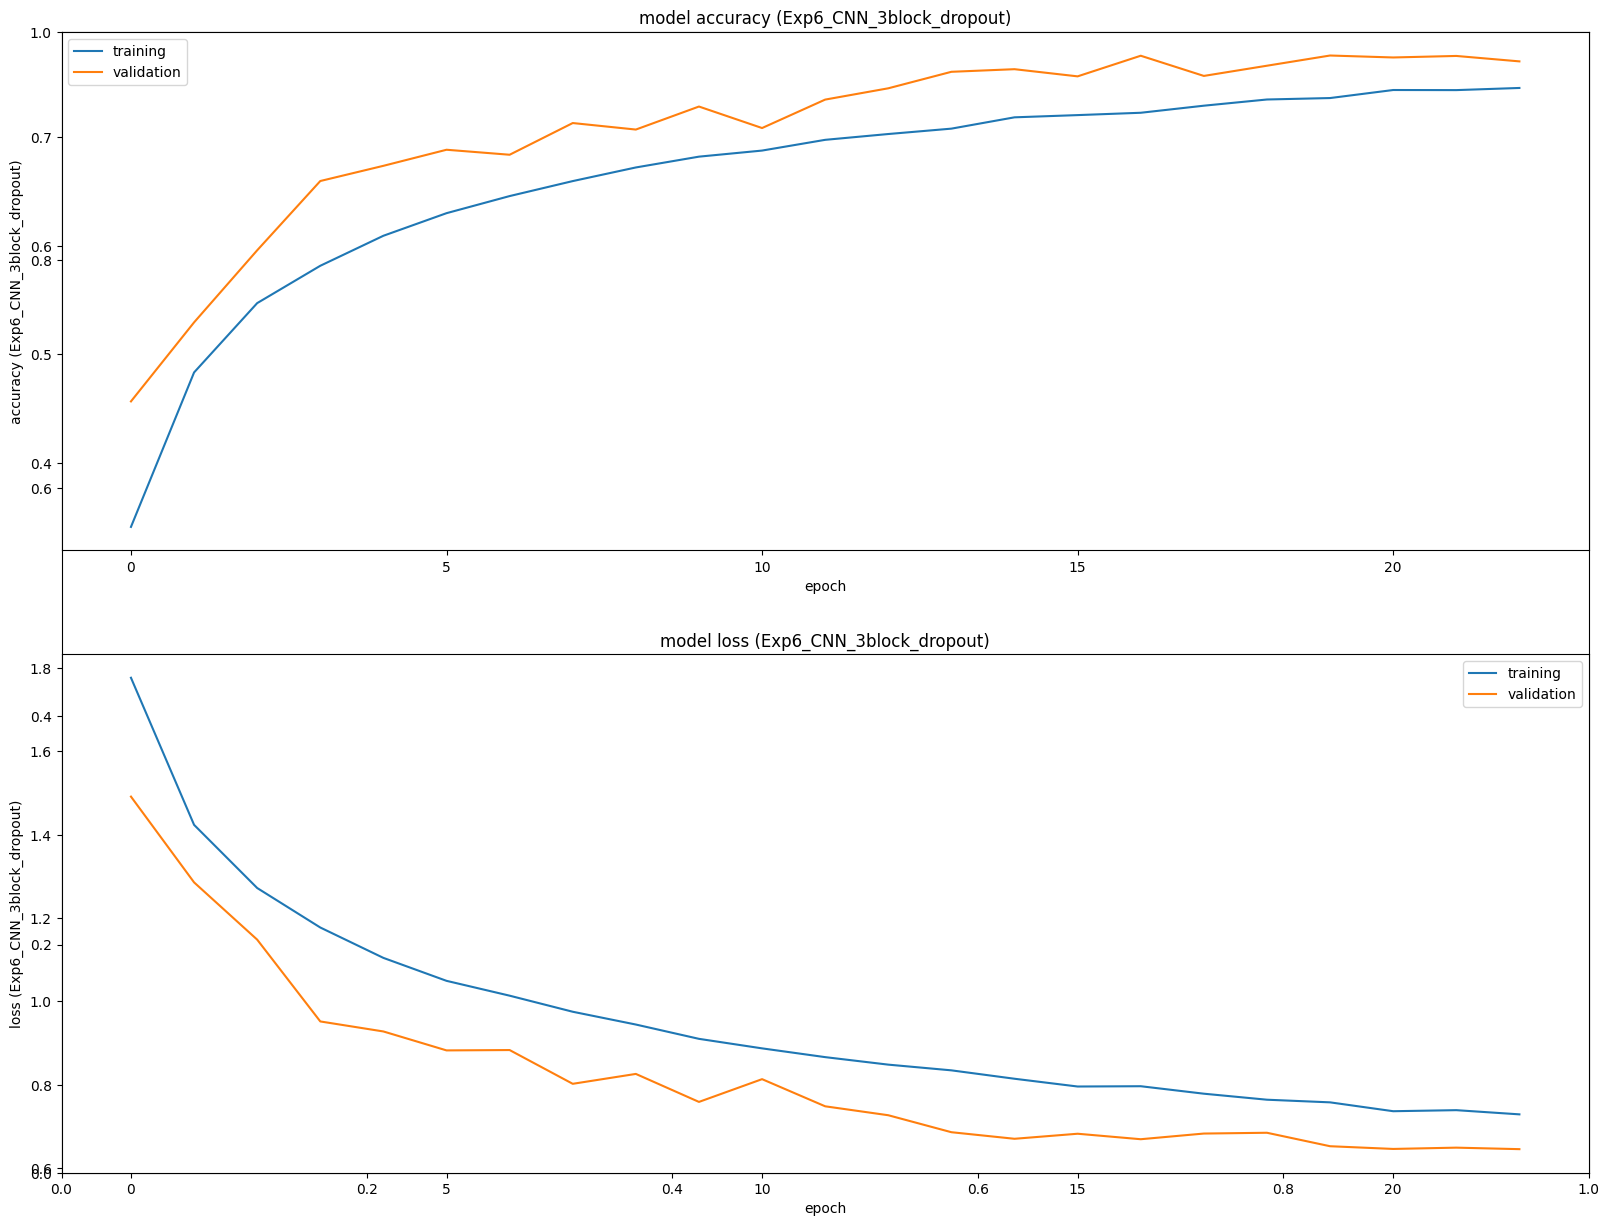

In [ ]:
history6, time6, path6, best6 = compile_train_model(
    cnn3_drop, exp_name6,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3
)

history_df6 = plot_history_df(history6, title=f"({exp_name6})")


In [ ]:
train_loss6, train_acc6 = best6.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss6, val_acc6     = best6.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss6, test_acc6   = best6.evaluate(x_test_norm, y_test, verbose=0)

print(f"Train acc: {train_acc6:.4f} | Train loss: {train_loss6:.4f}")
print(f"Val   acc: {val_acc6:.4f} | Val   loss: {val_loss6:.4f}")
print(f"Test  acc: {test_acc6:.4f} | Test  loss: {test_loss6:.4f}")
print("Saved best model to:", path6)

row6 = {
    "experiment": exp_name6,
    "params": best6.count_params(),
    "train_loss": float(train_loss6),
    "train_acc": float(train_acc6),
    "val_loss": float(val_loss6),
    "val_acc": float(val_acc6),
    "test_loss": float(test_loss6),
    "test_acc": float(test_acc6),
    "train_time_sec": float(time6),
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history6.history["loss"])
}

results_df = pd.concat([results_df, pd.DataFrame([row6])], ignore_index=True)
results_df


Train acc: 0.8460 | Train loss: 0.4495
Val   acc: 0.7698 | Val   loss: 0.6459
Test  acc: 0.7651 | Test  loss: 0.6822
Saved best model to: /content/models/Exp6_CNN_3block_dropout.keras


/tmp/ipython-input-2044557432.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row6])], ignore_index=True)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp6_CNN_3block_dropout,356810,0.449504,0.846,0.64592,0.7698,0.682221,0.7651,2794.48,adam,64,23


              precision    recall  f1-score   support

           0       0.82      0.77      0.79      1000
           1       0.91      0.87      0.89      1000
           2       0.74      0.58      0.65      1000
           3       0.61      0.58      0.59      1000
           4       0.66      0.80      0.72      1000
           5       0.68      0.66      0.67      1000
           6       0.73      0.87      0.80      1000
           7       0.85      0.78      0.81      1000
           8       0.81      0.91      0.86      1000
           9       0.88      0.83      0.85      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.76     10000
weighted avg       0.77      0.77      0.76     10000

Accuracy Score: 0.7651


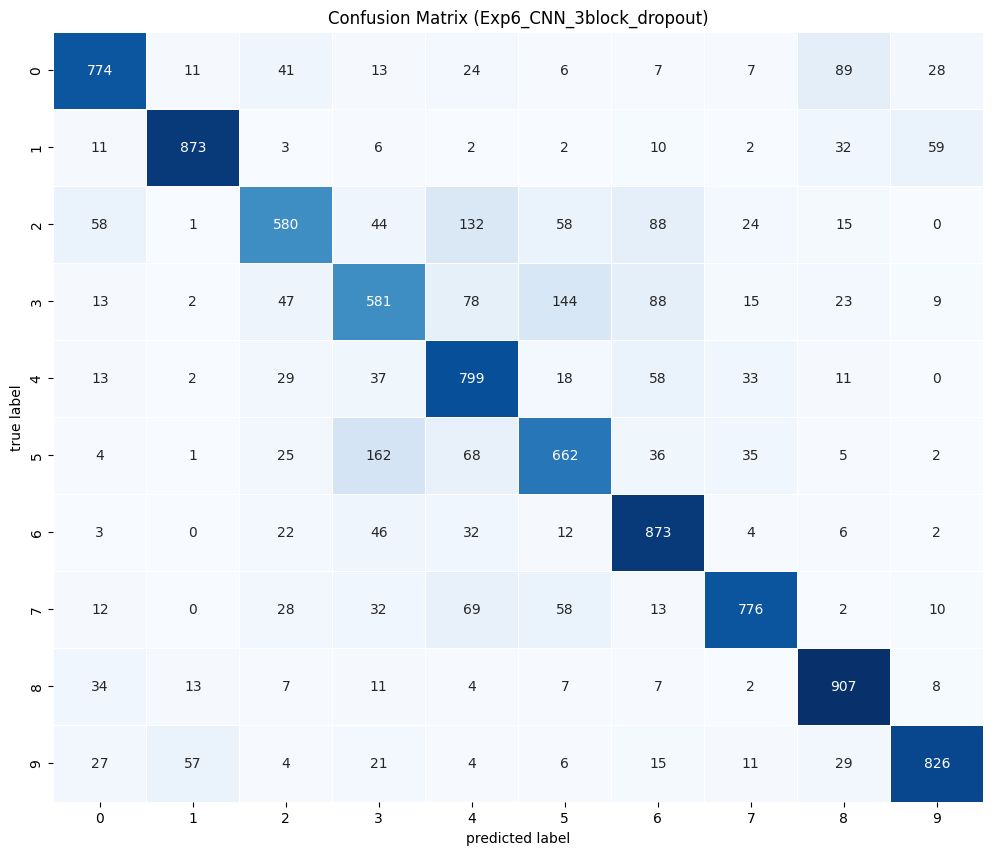

In [ ]:
y_pred6 = np.argmax(best6.predict(x_test_norm, verbose=0), axis=1)
y_true  = y_test.reshape(-1)

print(classification_report(y_true, y_pred6))
print("Accuracy Score:", accuracy_score(y_true, y_pred6))

plot_confusion_matrix(y_true, y_pred6, title=f"Confusion Matrix ({exp_name6})")


313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step


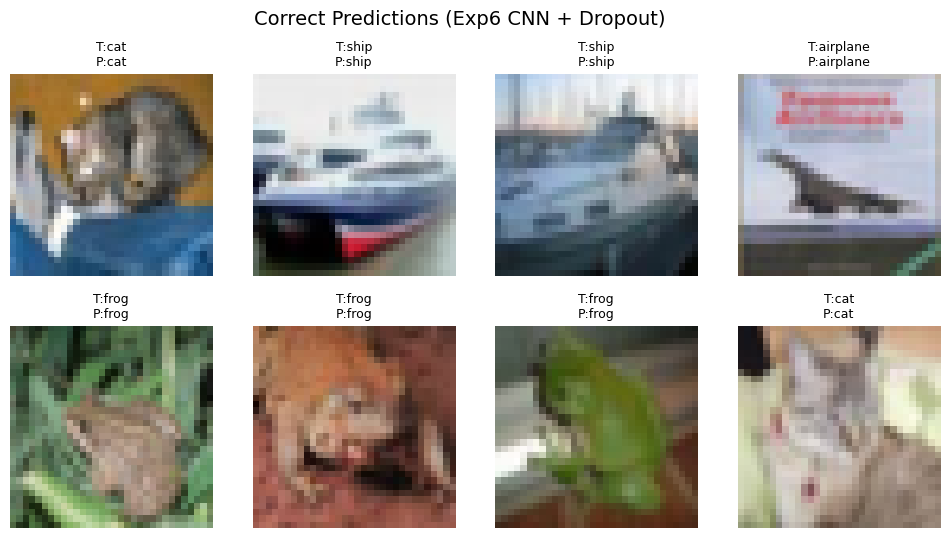

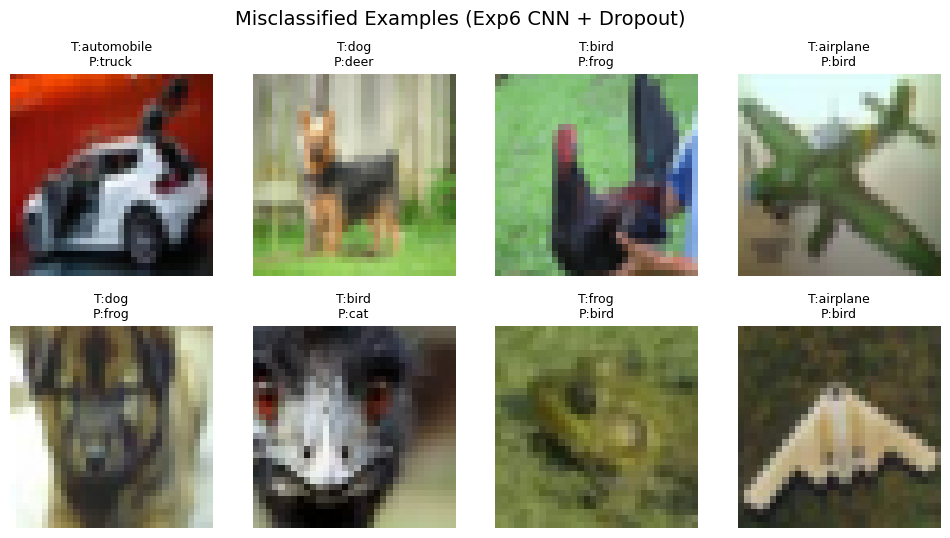

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Predictions
y_pred = np.argmax(best6.predict(x_test_norm), axis=1)
y_true = y_test.reshape(-1)

# Find correct and incorrect indices
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx   = np.where(y_pred != y_true)[0]

# Plot examples
def show_examples(indices, title):
    plt.figure(figsize=(12,6))
    for i, idx in enumerate(indices[:8]):
        plt.subplot(2,4,i+1)
        plt.imshow(x_test[idx])
        plt.axis("off")

        true_lab = class_names[y_true[idx]]
        pred_lab = class_names[y_pred[idx]]

        plt.title(f"T:{true_lab}\nP:{pred_lab}", fontsize=9)
    plt.suptitle(title, fontsize=14)
    plt.show()

# Show correct predictions
show_examples(correct_idx, "Correct Predictions (Exp6 CNN + Dropout)")

# Show incorrect predictions
show_examples(wrong_idx, "Misclassified Examples (Exp6 CNN + Dropout)")


# Experiment 7

In [ ]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Flatten, Dense,
    Dropout, BatchNormalization
)


In [ ]:
tf.keras.backend.clear_session()

exp_name7 = "Exp7_CNN_3block_batchnorm"

cnn3_bn = Sequential([
    Input(shape=(32, 32, 3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    BatchNormalization(),

    Dense(10, activation='softmax')
], name=exp_name7)

cnn3_bn.summary()


Model: "Exp7_CNN_3block_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 113ms/step - accuracy: 0.4948 - loss: 1.4509 - val_accuracy: 0.5332 - val_loss: 1.5311
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.7016 - loss: 0.8494 - val_accuracy: 0.6686 - val_loss: 0.9394
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.7682 - loss: 0.6607 - val_accuracy: 0.6630 - val_loss: 1.0396
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.8194 - loss: 0.5236 - val_accuracy: 0.7368 - val_loss: 0.7801
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.8534 - loss: 0.4258 - val_accuracy: 0.6672 - val_loss: 1.0497
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 109ms/step - accuracy: 0.8925 - loss: 0.3176 - val_accuracy: 0.6464 - val_loss: 1.2074
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8866 - loss: 0.3210 - val_accuracy: 0.6798 - val_loss: 1.1461
Finished Exp7_CNN_3block_batchnorm in 564.95s


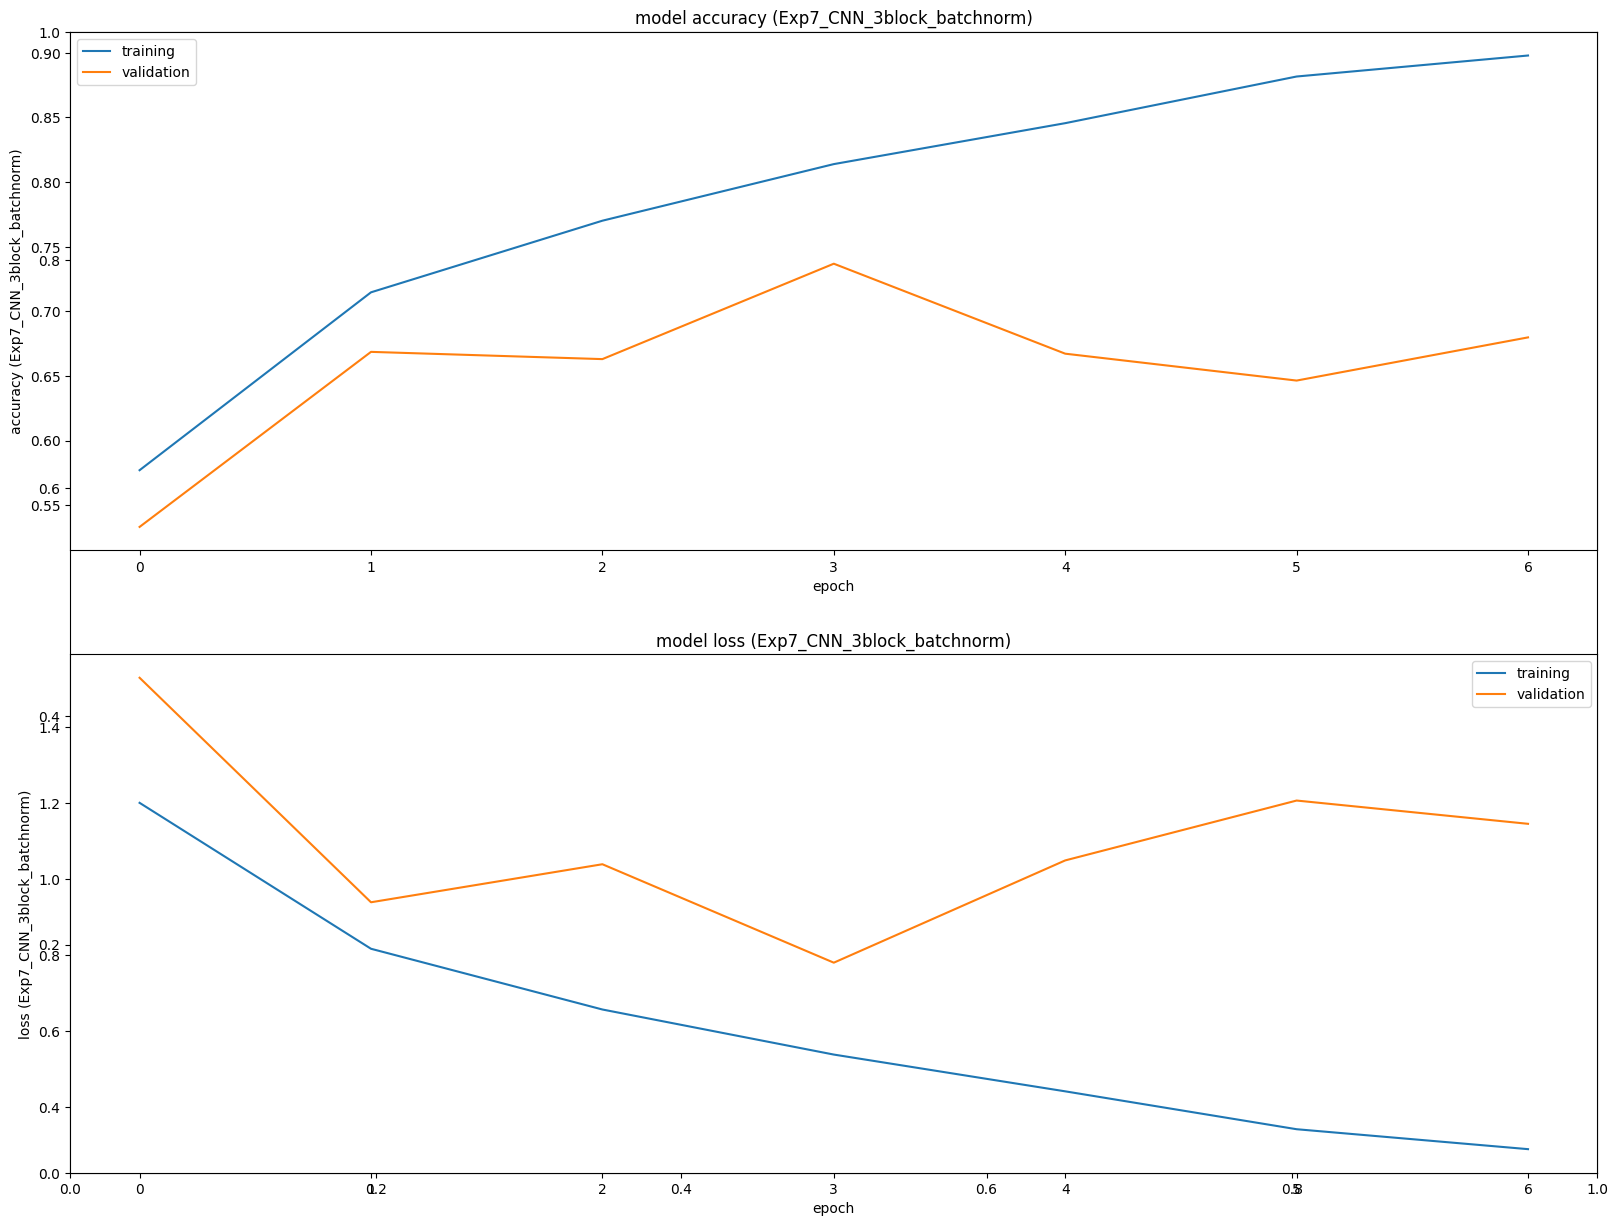

In [ ]:
history7, time7, path7, best7 = compile_train_model(
    cnn3_bn, exp_name7,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=3
)

history_df7 = plot_history_df(history7, title=f"({exp_name7})")


In [ ]:
test_loss, test_acc = cnn3_bn.evaluate(x_test_norm, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)




Test loss: 1.1972256898880005
Test accuracy: 0.6707000136375427


In [ ]:
train_loss7, train_acc7 = best7.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss7, val_acc7     = best7.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss7, test_acc7   = best7.evaluate(x_test_norm, y_test, verbose=0)

print(f"Train acc: {train_acc7:.4f} | Train loss: {train_loss7:.4f}")
print(f"Val   acc: {val_acc7:.4f} | Val   loss: {val_loss7:.4f}")
print(f"Test  acc: {test_acc7:.4f} | Test  loss: {test_loss7:.4f}")
print("Saved best model to:", path7)

row7 = {
    "experiment": exp_name7,
    "params": best7.count_params(),
    "train_loss": float(train_loss7),
    "train_acc": float(train_acc7),
    "val_loss": float(val_loss7),
    "val_acc": float(val_acc7),
    "test_loss": float(test_loss7),
    "test_acc": float(test_acc7),
    "train_time_sec": float(time7),
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history7.history["loss"])
}

results_df = pd.concat([results_df, pd.DataFrame([row7])], ignore_index=True)
results_df


              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1000
           1       0.85      0.84      0.84      1000
           2       0.79      0.50      0.62      1000
           3       0.58      0.54      0.56      1000
           4       0.68      0.71      0.70      1000
           5       0.65      0.63      0.64      1000
           6       0.79      0.78      0.78      1000
           7       0.67      0.87      0.76      1000
           8       0.87      0.79      0.83      1000
           9       0.74      0.88      0.80      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000

Accuracy Score: 0.7331


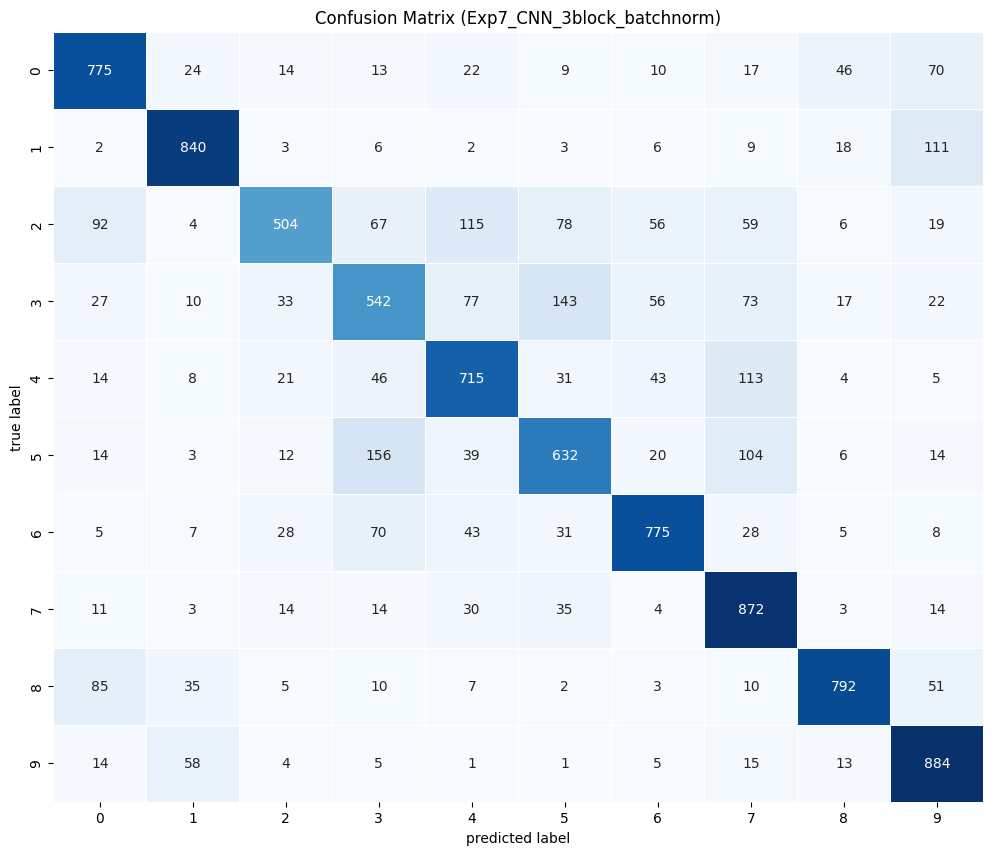

In [ ]:
y_pred7 = np.argmax(best7.predict(x_test_norm, verbose=0), axis=1)
y_true = y_test.reshape(-1)

print(classification_report(y_true, y_pred7))
print("Accuracy Score:", accuracy_score(y_true, y_pred7))

plot_confusion_matrix(y_true, y_pred7, title=f"Confusion Matrix ({exp_name7})")


Total wrong predictions: 2669


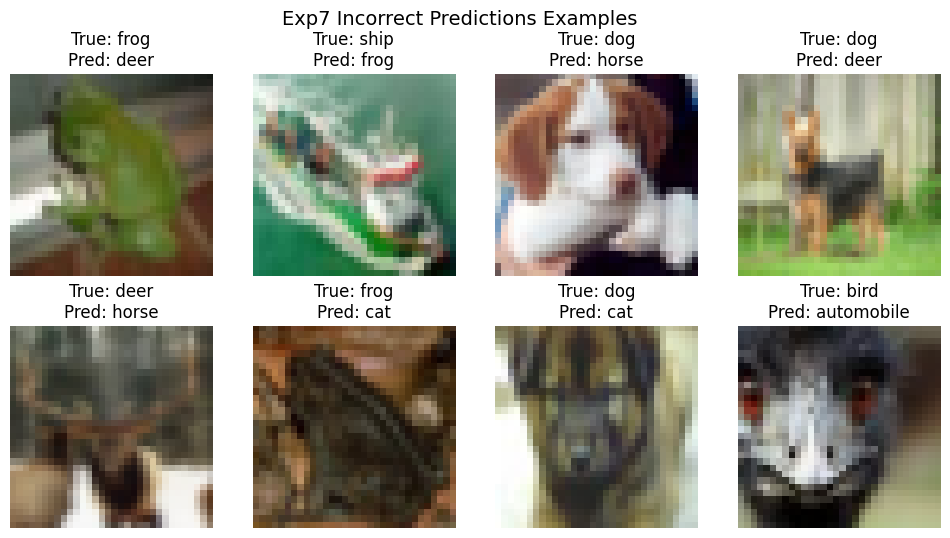

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Predict probabilities
y_probs7 = best7.predict(x_test_norm, verbose=0)
y_pred7 = np.argmax(y_probs7, axis=1)
y_true7 = y_test.reshape(-1)

# Find incorrect predictions
wrong_idx = np.where(y_pred7 != y_true7)[0]

print("Total wrong predictions:", len(wrong_idx))

# Plot 8 incorrect examples
plt.figure(figsize=(12,6))

for i, idx in enumerate(wrong_idx[:8]):
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true7[idx]]}\nPred: {class_names[y_pred7[idx]]}")
    plt.axis("off")

plt.suptitle("Exp7 Incorrect Predictions Examples", fontsize=14)
plt.show()


In [ ]:
print("best7.inputs:", best7.inputs)
print("best7.outputs:", best7.outputs)
print("num layers:", len(best7.layers))


best7.inputs: [<KerasTensor shape=(None, 32, 32, 3), dtype=float32, sparse=False, ragged=False, name=input_layer>]
best7.outputs: [<KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_286>]
num layers: 13


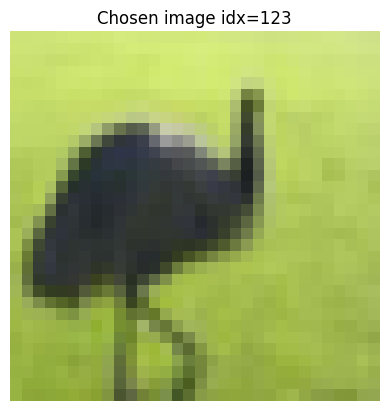

MaxPool #1 activation shape: (1, 16, 16, 32)
MaxPool #2 activation shape: (1, 8, 8, 64)


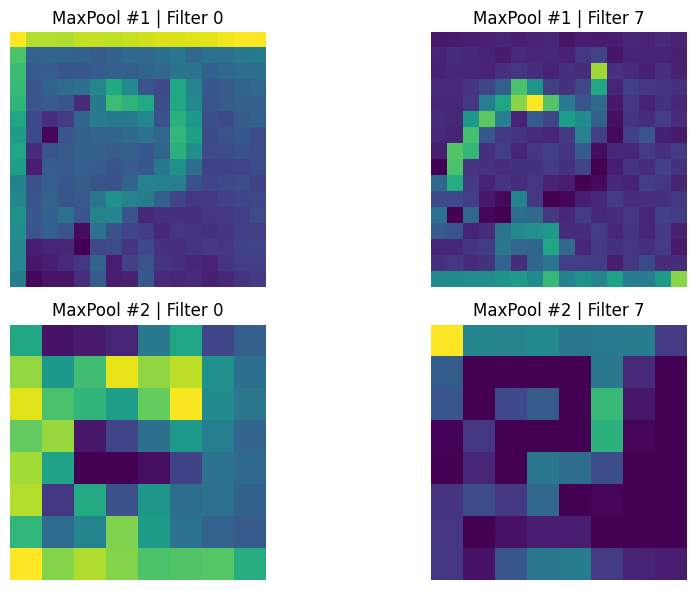

In [ ]:
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


img_idx = 123
sample_img = x_test_norm[img_idx:img_idx+1]

plt.imshow(x_test[img_idx])
plt.title(f"Chosen image idx={img_idx}")
plt.axis("off")
plt.show()

inp = best7.inputs[0]


act_model_1 = Model(inputs=inp, outputs=best7.layers[2].output)
act_model_2 = Model(inputs=inp, outputs=best7.layers[5].output)

act1 = act_model_1(sample_img, training=False).numpy()
act2 = act_model_2(sample_img, training=False).numpy()

print("MaxPool #1 activation shape:", act1.shape)
print("MaxPool #2 activation shape:", act2.shape)

plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.imshow(act1[0,:,:,0], cmap="viridis")
plt.title("MaxPool #1 | Filter 0")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(act1[0,:,:,7], cmap="viridis")
plt.title("MaxPool #1 | Filter 7")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(act2[0,:,:,0], cmap="viridis")
plt.title("MaxPool #2 | Filter 0")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(act2[0,:,:,7], cmap="viridis")
plt.title("MaxPool #2 | Filter 7")
plt.axis("off")

plt.tight_layout()
plt.show()


Total misclassified: 2669 out of 10000


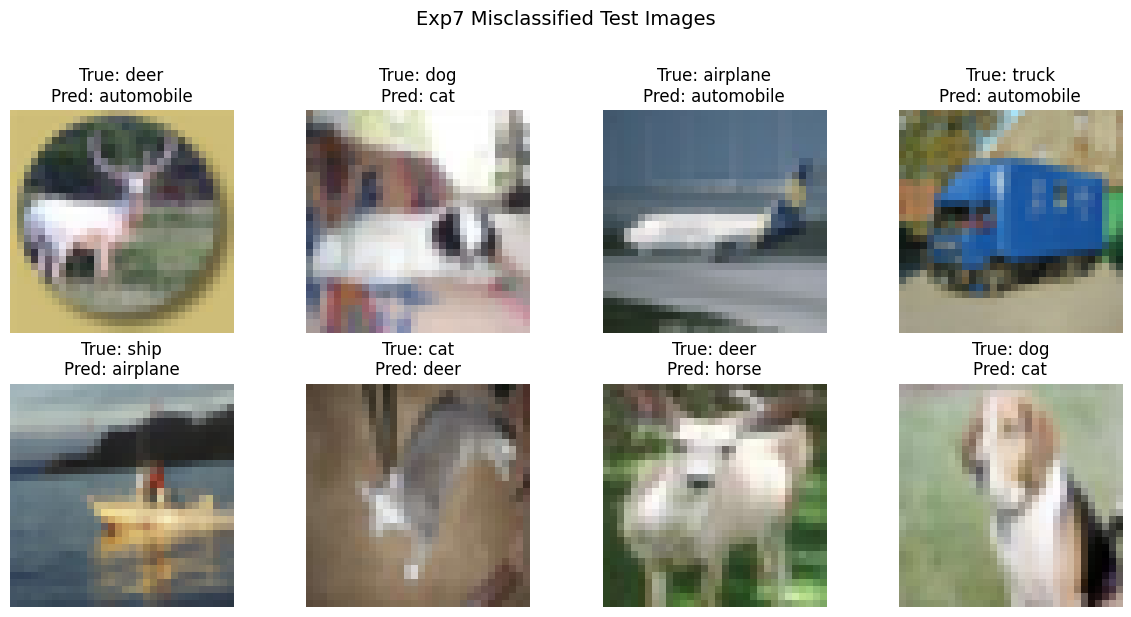

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# --- Misclassified examples (Exp7) ---
n_show = 8
rng_seed = 42

# Predict on test set
y_prob = best7.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.reshape(-1)

# Find misclassified indices
wrong_idx = np.where(y_pred != y_true)[0]
print("Total misclassified:", len(wrong_idx), "out of", len(y_true))

# Pick random sample of wrong predictions
np.random.seed(rng_seed)
pick = np.random.choice(wrong_idx, size=min(n_show, len(wrong_idx)), replace=False)

# Plot grid
plt.figure(figsize=(12,6))
for i, idx in enumerate(pick):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    plt.title(
        f"True: {class_names[int(y_true[idx])]}\nPred: {class_names[int(y_pred[idx])]}"
    )
plt.suptitle("Exp7 Misclassified Test Images", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


# Experiment 8

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train_split, x_valid_split, y_train_split, y_valid_split = train_test_split(
    x_train, y_train, test_size=0.10, random_state=SEED, shuffle=True
)

x_train_norm = x_train_split.astype("float32") / 255.0
x_valid_norm = x_valid_split.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

print("Train:", x_train_norm.shape, y_train_split.shape)
print("Valid:", x_valid_norm.shape, y_valid_split.shape)
print("Test :", x_test_norm.shape,  y_test.shape)

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (45000, 32, 32, 3) (45000, 1)
Valid: (5000, 32, 32, 3) (5000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [ ]:
def display_training_curves(training, validation, title, subplot):
    ax = plt.subplot(subplot)
    ax.plot(training)
    ax.plot(validation)
    ax.set_title('model ' + title)
    ax.set_ylabel(title)
    ax.set_xlabel('epoch')
    ax.legend(['training', 'validation'])

def plot_history_df(history, exp_title=""):
    df = pd.DataFrame(history.history)
    plt.subplots(figsize=(16,12))
    plt.tight_layout()
    display_training_curves(df['accuracy'], df['val_accuracy'], f'accuracy {exp_title}', 211)
    display_training_curves(df['loss'], df['val_loss'], f'loss {exp_title}', 212)
    plt.show()
    return df

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    mtx = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12,9))
    sns.heatmap(mtx, annot=True, fmt='d', linewidths=.5, cbar=False,
                ax=ax, cmap='Blues', linecolor='white')
    ax.set_xlabel('predicted label')
    ax.set_ylabel('true label')
    ax.set_title(title)
    plt.show()

def compile_train_model(model, exp_name,
                        x_train, y_train,
                        x_valid, y_valid,
                        optimizer='adam',
                        batch_size=64,
                        epochs=200,
                        patience=5,
                        save_dir="/content/models"):

    os.makedirs(save_dir, exist_ok=True)
    ckpt_path = os.path.join(save_dir, f"{exp_name}.keras")

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=True, save_weights_only=False),
        EarlyStopping(monitor='val_accuracy', patience=patience, restore_best_weights=False)
    ]

    t0 = time.time()
    history = model.fit(
        x_train, y_train,
        validation_data=(x_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    train_time = round(time.time() - t0, 2)
    print(f"Finished {exp_name} in {train_time}s")
    return history, train_time, ckpt_path


In [ ]:
tf.keras.backend.clear_session()

exp_name8 = "Exp8_CNN_3block_batchnorm_dropout"

cnn3_bn_do = Sequential([
    Input(shape=(32,32,3)),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.40),

    Dense(10, activation='softmax')
], name=exp_name8)

cnn3_bn_do.summary()


Model: "Exp8_CNN_3block_batchnorm_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 187s 253ms/step - accuracy: 0.3704 - loss: 1.9345 - val_accuracy: 0.5220 - val_loss: 1.3277
Epoch 2/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.5643 - loss: 1.2209 - val_accuracy: 0.5928 - val_loss: 1.1057
Epoch 3/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 169s 240ms/step - accuracy: 0.6256 - loss: 1.0574 - val_accuracy: 0.6786 - val_loss: 0.9268
Epoch 4/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 162s 229ms/step - accuracy: 0.6585 - loss: 0.9712 - val_accuracy: 0.6998 - val_loss: 0.8446
Epoch 5/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 234ms/step - accuracy: 0.6799 - loss: 0.9065 - val_accuracy: 0.6634 - val_loss: 0.9642
Epoch 6/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.7062 - loss: 0.8395 - val_accuracy: 0.6104 - val_loss: 1.1970
Epoch 7/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 162s 230ms/step - accuracy: 0.7171 - loss: 0.8089 - val_accuracy: 0.6782 - val_loss: 0.9310
Epoch 8/200
704/704 ━━━━━━━━━━━━━━━━━━━━ 155s 220ms/step - accuracy: 

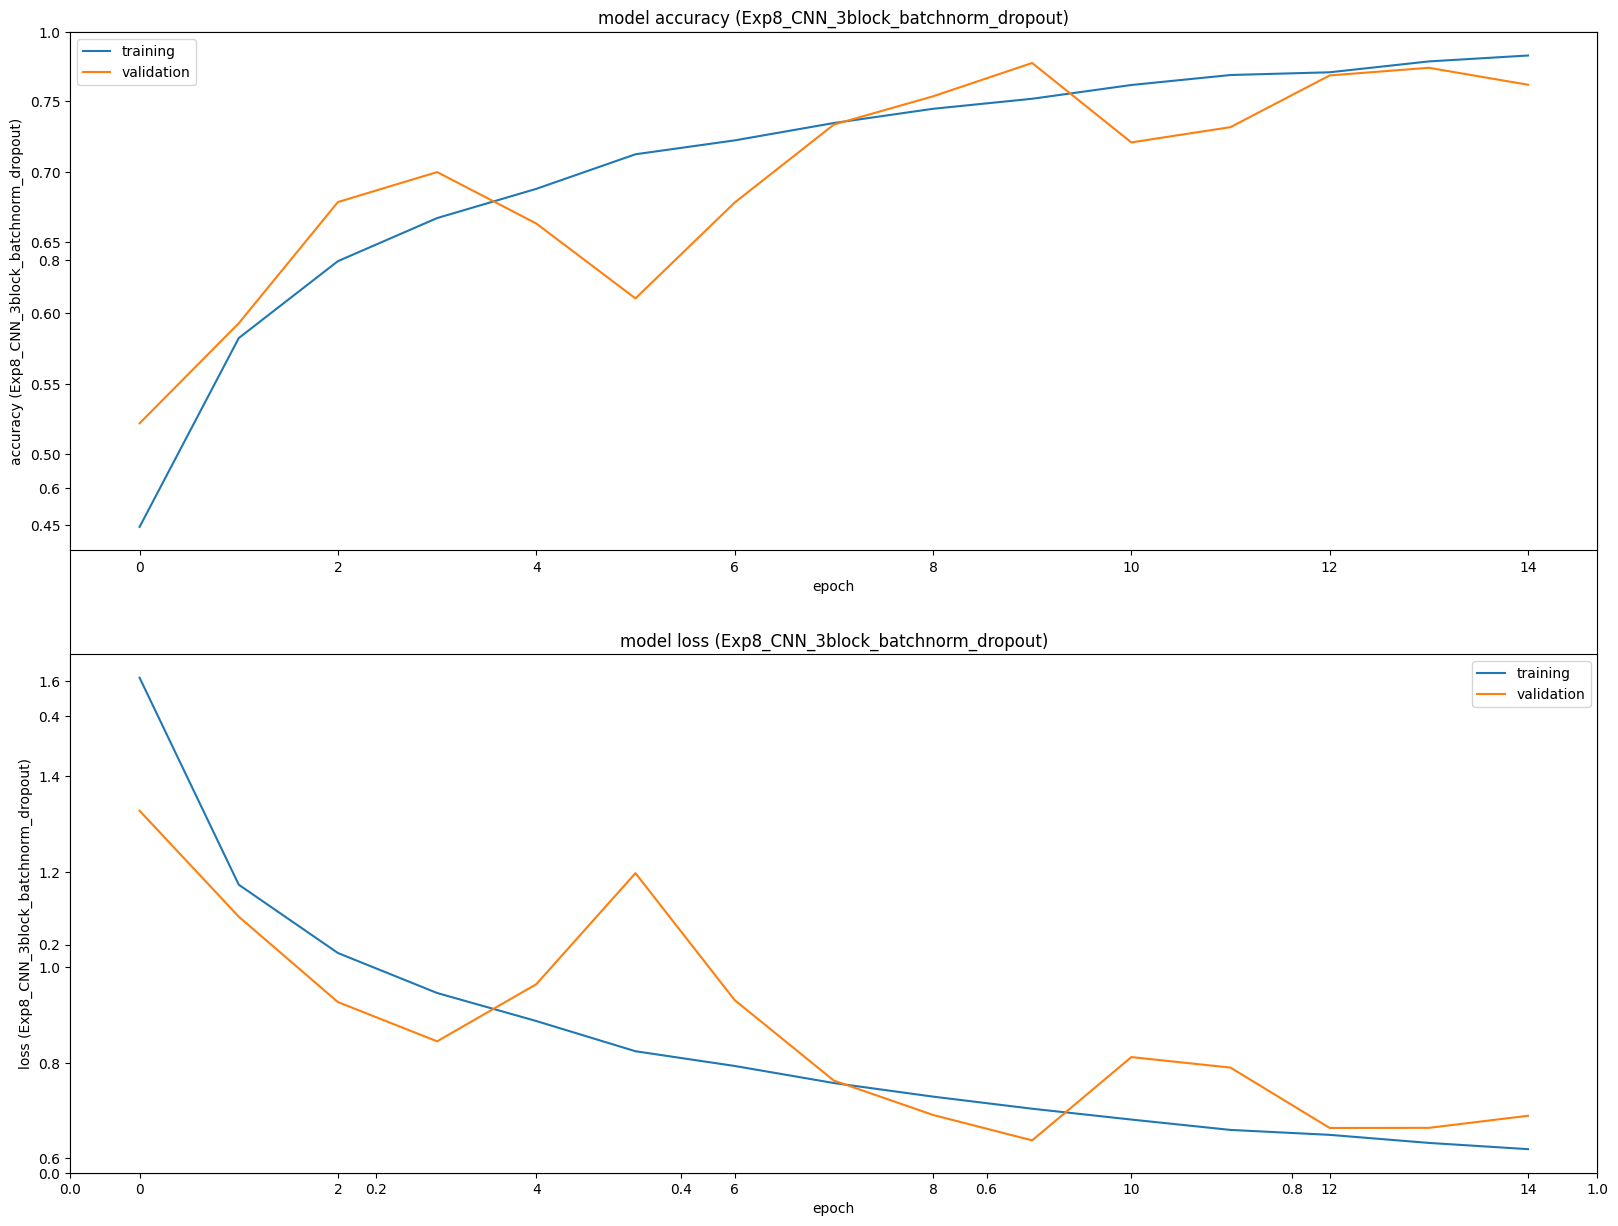

Saved best model to: /content/models/Exp8_CNN_3block_batchnorm_dropout.keras


In [ ]:
history8, time8, path8 = compile_train_model(
    cnn3_bn_do, exp_name8,
    x_train_norm, y_train_split,
    x_valid_norm, y_valid_split,
    optimizer='adam',
    batch_size=64,
    epochs=200,
    patience=5
)

history_df8 = plot_history_df(history8, exp_title=f"({exp_name8})")
print("Saved best model to:", path8)


In [ ]:
best8 = load_model(path8)

train_loss8, train_acc8 = best8.evaluate(x_train_norm, y_train_split, verbose=0)
val_loss8, val_acc8     = best8.evaluate(x_valid_norm, y_valid_split, verbose=0)
test_loss8, test_acc8   = best8.evaluate(x_test_norm,  y_test,        verbose=0)

print(f"Train acc: {train_acc8:.4f} | Train loss: {train_loss8:.4f}")
print(f"Val   acc: {val_acc8:.4f} | Val   loss: {val_loss8:.4f}")
print(f"Test  acc: {test_acc8:.4f} | Test  loss: {test_loss8:.4f}")


Train acc: 0.8349 | Train loss: 0.4772
Val   acc: 0.7770 | Val   loss: 0.6371
Test  acc: 0.7735 | Test  loss: 0.6541


Classification Report (Exp8)
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1000
           1       0.89      0.89      0.89      1000
           2       0.71      0.62      0.66      1000
           3       0.58      0.64      0.61      1000
           4       0.76      0.71      0.73      1000
           5       0.72      0.64      0.67      1000
           6       0.84      0.84      0.84      1000
           7       0.79      0.83      0.81      1000
           8       0.83      0.91      0.87      1000
           9       0.83      0.86      0.84      1000

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000

Accuracy Score: 0.7735


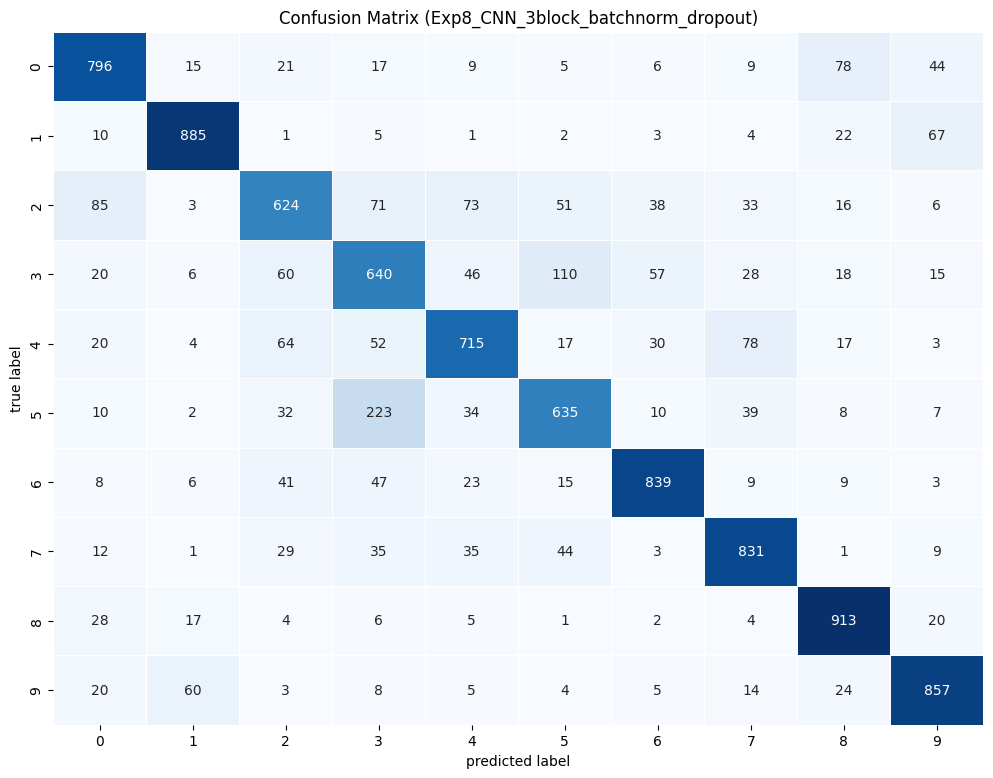

Total misclassified: 2265 out of 10000


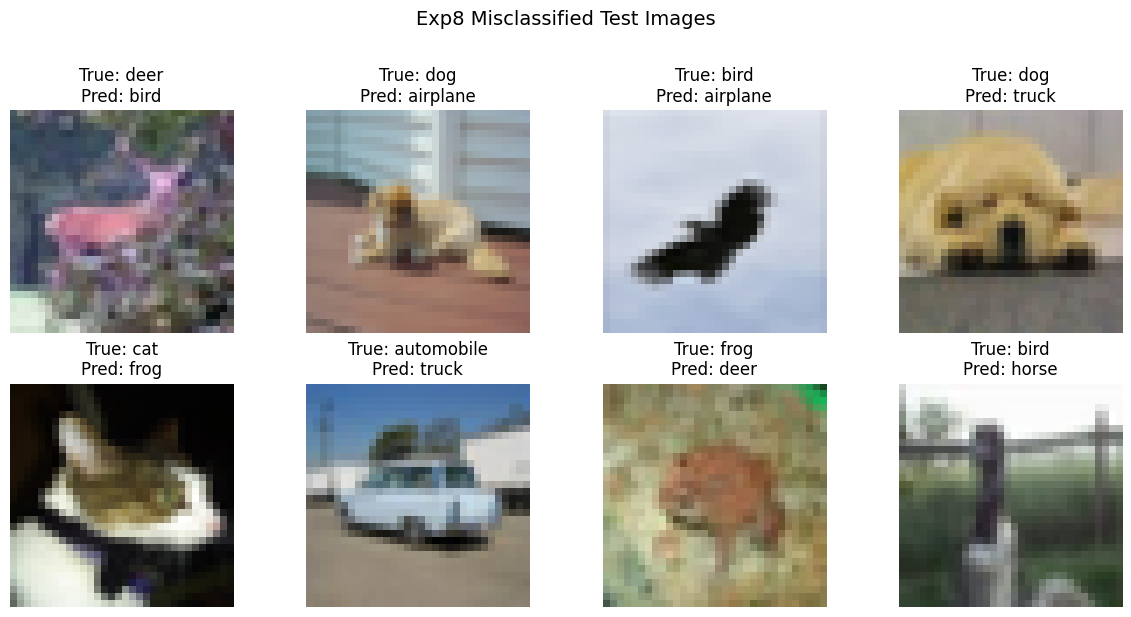

In [ ]:
y_prob8 = best8.predict(x_test_norm, verbose=0)
y_pred8 = np.argmax(y_prob8, axis=1)
y_true  = y_test.reshape(-1)

print("Classification Report (Exp8)")
print(classification_report(y_true, y_pred8))
print("Accuracy Score:", accuracy_score(y_true, y_pred8))

plot_confusion_matrix(y_true, y_pred8, title=f"Confusion Matrix ({exp_name8})")

# Misclassified grid (8)
n_show = 8
rng_seed = 42

wrong_idx = np.where(y_pred8 != y_true)[0]
print("Total misclassified:", len(wrong_idx), "out of", len(y_true))

np.random.seed(rng_seed)
pick = np.random.choice(wrong_idx, size=min(n_show, len(wrong_idx)), replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(pick):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_test[idx])
    plt.axis("off")
    plt.title(f"True: {class_names[int(y_true[idx])]}\nPred: {class_names[int(y_pred8[idx])]}")
plt.suptitle("Exp8 Misclassified Test Images", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
cols = ["experiment","params","train_loss","train_acc","val_loss","val_acc","test_loss","test_acc",
        "train_time_sec","optimizer","batch_size","epochs_ran"]

if "results_df" not in globals():
    results_df = pd.DataFrame(columns=cols)

row8 = {
    "experiment": exp_name8,
    "params": best8.count_params(),
    "train_loss": float(train_loss8),
    "train_acc": float(train_acc8),
    "val_loss": float(val_loss8),
    "val_acc": float(val_acc8),
    "test_loss": float(test_loss8),
    "test_acc": float(test_acc8),
    "train_time_sec": float(time8),
    "optimizer": "adam",
    "batch_size": 64,
    "epochs_ran": len(history8.history["loss"])
}

results_df = pd.concat([results_df, pd.DataFrame([row8])], ignore_index=True)
results_df.tail(12)


/tmp/ipython-input-2101228185.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([row8])], ignore_index=True)


,experiment,params,train_loss,train_acc,val_loss,val_acc,test_loss,test_acc,train_time_sec,optimizer,batch_size,epochs_ran
0,Exp8_CNN_3block_batchnorm_dropout,358218,0.477204,0.834933,0.637082,0.777,0.654134,0.7735,2657.3,adam,64,15
